In [18]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv

load_dotenv()

True

In [19]:
llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
)


In [20]:
# State
class BlogState(TypedDict):
    topic: str
    outline: str
    blog: str

In [21]:
def generate_outline(state: BlogState) -> BlogState:
    topic = state["topic"]

    response = llm.invoke(
        f"Create a detailed blog outline on: {topic}"
    )

    state["outline"] = response.content
    return state

In [22]:
def generate_blog(state: BlogState) -> BlogState:
    outline = state["outline"]

    response = llm.invoke(
        f"Write a complete blog using this outline:\n{outline}"
    )

    state["blog"] = response.content
    return state

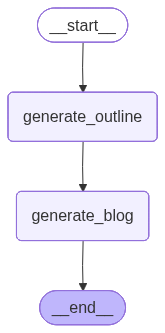

In [23]:
graph = StateGraph(BlogState)

graph.add_node("generate_outline", generate_outline)
graph.add_node("generate_blog", generate_blog)

graph.add_edge(START, "generate_outline")
graph.add_edge("generate_outline", "generate_blog")
graph.add_edge("generate_blog", END)

workflow = graph.compile()

workflow

In [24]:
result = workflow.invoke({
    "topic": "Artificial Intelligence"
})

print(result)

{'topic': 'Artificial Intelligence', 'outline': 'Here\'s a detailed blog outline on Artificial Intelligence, designed to be comprehensive, engaging, and easy to follow for a general audience with an interest in technology.\n\n---\n\n## Blog Title Options:\n\n*   **Unlocking the Future: A Deep Dive into Artificial Intelligence**\n*   **Beyond the Hype: Demystifying the World of AI**\n*   **The AI Revolution: Understanding the Technology Shaping Our World**\n*   **From Sci-Fi to Reality: Your Essential Guide to Artificial Intelligence**\n\n---\n\n## Meta Description Suggestion:\n\n"Explore the fascinating world of Artificial Intelligence! This comprehensive guide demystifies AI, covering its history, how it works, real-world applications, ethical considerations, and what the future holds for this transformative technology."\n\n---\n\n## Blog Outline:\n\n### I. Introduction (Approx. 150-200 words)\n\n*   **A. Hook:**\n    *   Start with a captivating question or statement about AI\'s omni

In [25]:
print(result["blog"])

Okay, here is a complete blog post based on your detailed outline.

---

## The AI Revolution: Understanding the Technology Shaping Our World

**Meta Description:** "Explore the fascinating world of Artificial Intelligence! This comprehensive guide demystifies AI, covering its history, how it works, real-world applications, ethical considerations, and what the future holds for this transformative technology."

***

### I. Introduction

From recommending your next movie to powering self-driving cars, Artificial Intelligence is no longer a futuristic concept—it's woven into the fabric of our daily lives. This omnipresence often sparks a mix of excitement for the possibilities it unlocks and apprehension about its profound implications. But what exactly is AI? At its core, it's the simulation of human intelligence processes by machines, especially computer systems, designed to learn, reason, and solve problems.

In an era of rapid technological advancement, AI stands out as a critical for